##Exp-10

##Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

##Load and Inspect Data

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AML_Lab_B19/Exp-10 Iris Flower Classification/IRIS.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nUnique species:", df['species'].unique())
print("\nMissing values:\n", df.isnull().sum())

Dataset shape: (150, 5)

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Unique species: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


##Prepare Features and Target

In [3]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

# Encode target labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Encoded species:", dict(zip(le.classes_, le.transform(le.classes_))))

Encoded species: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


##Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (120, 4)
Test set: (30, 4)


##Train Model

In [6]:
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


##Predict and Evaluate

In [7]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9666666666666667

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

##Visualize Predictions

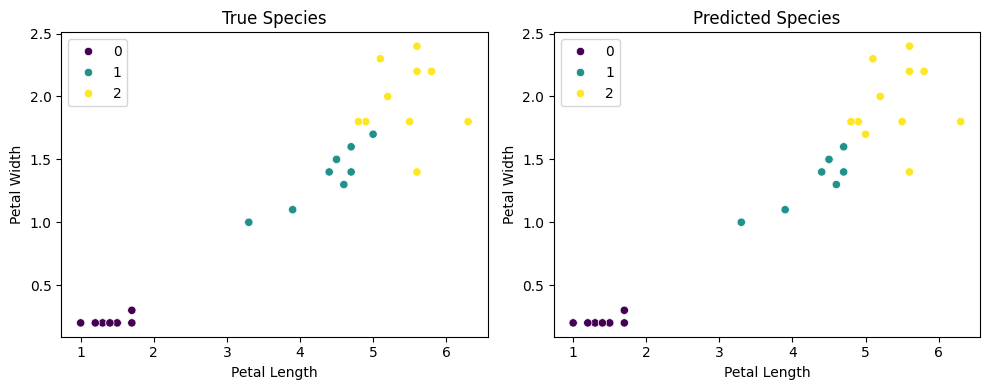

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_test['petal_length'], y=X_test['petal_width'], hue=y_test, palette='viridis')
plt.title('True Species')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_test['petal_length'], y=X_test['petal_width'], hue=y_pred, palette='viridis')
plt.title('Predicted Species')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.tight_layout()
plt.show()

In [10]:
# Binarize labels for multiclass ROC (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

# Get prediction probabilities
y_prob = model.predict_proba(X_test)

# Compute ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

print("Per-class AUC:", {le.classes_[i]: roc_auc[i] for i in range(n_classes)})

Per-class AUC: {'Iris-setosa': np.float64(1.0), 'Iris-versicolor': np.float64(1.0), 'Iris-virginica': np.float64(1.0)}


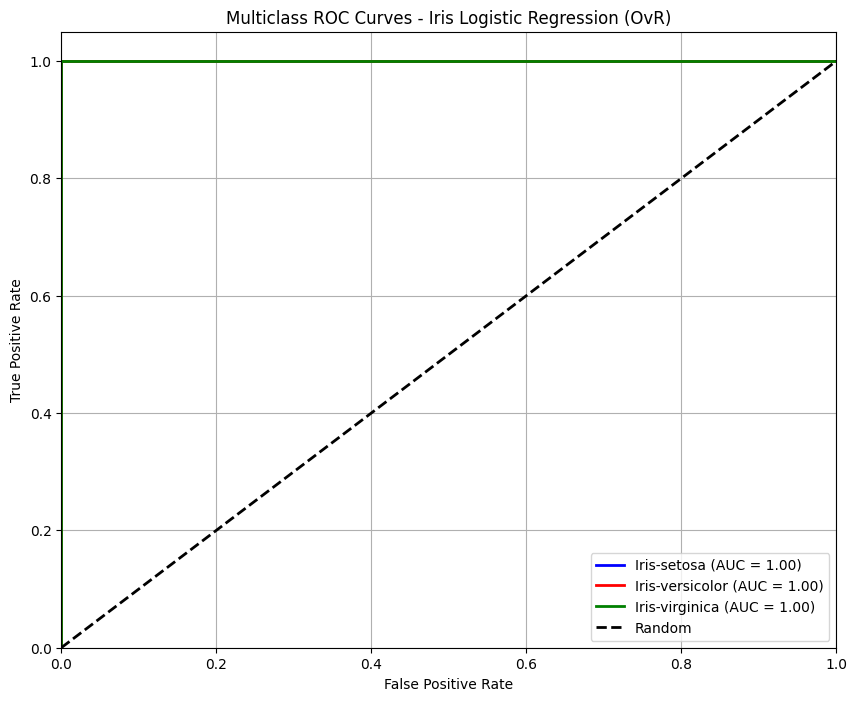

In [11]:
# Plot ROC curves for all classes
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves - Iris Logistic Regression (OvR)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [12]:
# Micro-average ROC (global)
from sklearn.metrics import roc_auc_score
y_prob_micro = np.array([y_prob[:, i] for i in range(n_classes)]).T
roc_auc_micro = roc_auc_score(y_test_bin, y_prob_micro, multi_class='ovr', average='micro')
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

# Macro-average AUC
roc_auc_macro = roc_auc_score(y_test_bin, y_prob_micro, multi_class='ovr', average='macro')
print(f"Macro-average AUC: {roc_auc_macro:.3f}")

Micro-average AUC: 0.999
Macro-average AUC: 1.000
